In [122]:
from idlelib import history

import pandas as pd
from keras.src.layers import MaxPooling2D, Activation
from tensorflow.keras.models import Sequential                                      # nn layer-by-layer
from tensorflow.keras.layers import Dense, Input, Conv2D, MaxPool2D, Flatten        #layer
from keras.utils import plot_model
from keras.datasets import mnist                                                    # 0 - 9
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.python.keras.saving.saved_model_experimental import sequential

In [123]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train.shape, x_test.shape

((60000, 28, 28), (10000, 28, 28))

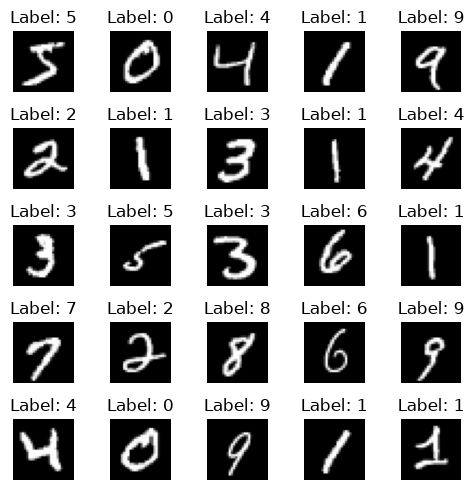

In [124]:
plt.figure(figsize=(5,5))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

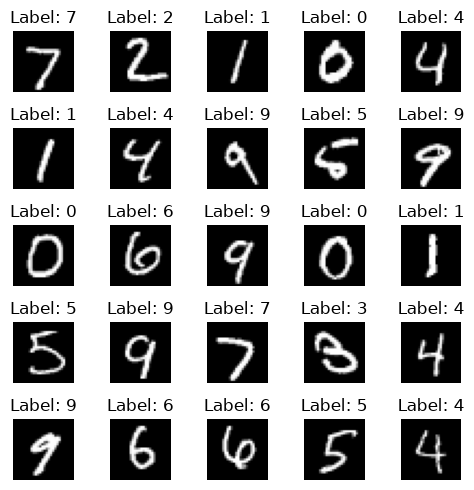

In [125]:
plt.figure(figsize=(5,5))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"Label: {y_test[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [126]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [127]:
print("Normalized training shape:", x_train.shape)
print("Normalized test shape:", x_test.shape)

Normalized training shape: (60000, 28, 28)
Normalized test shape: (10000, 28, 28)


In [128]:
model = Sequential()
model.add(Input(shape=(28,28,1)))
model.add(Conv2D(activation='relu', filters=16, kernel_size=(3,3)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(activation='relu', filters=32, kernel_size=(3,3)))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 3872)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       991,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 998,858 (3.81 MB)

 Trainable params: 998,858 (3.81 MB)

 Non-trainable params: 0 (0.00 B)

In [129]:
model.compile(optimizer='adam', metrics=['accuracy'], loss='sparse_categorical_crossentropy')

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=10
)

Epoch 1/10
5630/6000 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9667 - loss: 0.1079 

In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

In [ ]:
import os

print(os.getcwd())
print(os.listdir())

In [ ]:
import cv2

image_files = ["new-char.png", "new-char1.jpg"]

for filename in image_files:

    img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print("Could not read:", filename)
        continue

    img = cv2.resize(img, (28, 28))

    thresh, new = cv2.threshold(
        img,
        127,
        255,
        cv2.THRESH_BINARY
    )

    new = new / 255.0

    new = new.reshape(1, 28, 28, 1)

    result = model.predict(new, verbose=0)

    prediction = np.argmax(result)

    print("Image:", filename)
    print("Predicted digit:", prediction)
    print()

    plt.figure(figsize=(3,3))
    plt.imshow(new.reshape(28,28), cmap='gray')
    plt.title(f"Predicted Digit: {prediction}")
    plt.axis("off")
    plt.show()